# Multimodal Fake News Detection with CLIP

Classifies a news post as **real** or **fake** from its image *and* its caption.
Both are encoded with CLIP (`openai/clip-vit-base-patch32`), the two embeddings are
averaged, and a small classification head is fine-tuned together with CLIP.

**Validation results (2,500 posts, balanced):** accuracy 0.958, macro-F1 0.958.

Contents:
1. Setup and configuration
2. Data loading
3. Model
4. Training with resumable checkpoints
5. Evaluation
6. Inference on the unlabeled test set
7. Predicting a single image + caption, and a Gradio demo


## 1. Setup and configuration

In [16]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# ---- Repro ----
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# -------------------------------------------------
# Config
# -------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = "."
CKPT_DIR = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

MODEL_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 16
MAX_SEQ_LENGTH = 77  # CLIP's maximum text length

LR = 1e-5
EPOCHS = 5


## 2. Data loading
The dataset is stored as parquet files where each row contains the image bytes, the caption text and a binary label (0 = fake, 1 = real).

In [17]:
import io
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import CLIPProcessor

train = pd.read_parquet(os.path.join(DATA_DIR, "train-00000-of-00001.parquet"))
val   = pd.read_parquet(os.path.join(DATA_DIR, "validation-00000-of-00001.parquet"))

# Optional: test files
test_files = sorted(glob.glob(os.path.join(DATA_DIR, "test-*.parquet")))
test = pd.concat([pd.read_parquet(f) for f in test_files], ignore_index=True)

# Use HuggingFace CLIP processor
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

class MultiModalNewsDataset(Dataset):
    def __init__(self, df, processor, text_col, image_col, label_col):
        self.captions = df[text_col].tolist()
        self.images = df[image_col].tolist()
        self.labels = df[label_col].tolist()
        self.processor = processor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image_bytes = self.images[idx]['bytes']
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        caption = self.captions[idx]

        # Process individually (we'll pad in collate_fn)
        processed = self.processor(
            text=caption,
            images=image,
            return_tensors="pt",
            padding=False,        # padding is done per batch in collate_fn
            truncation=True,      # truncate long captions
            max_length=MAX_SEQ_LENGTH,
        )

        processed = {k: v.squeeze(0) for k, v in processed.items()}
        processed["labels"] = torch.tensor(self.labels[idx])
        return processed

train_dataset = MultiModalNewsDataset(train, processor, text_col="text", image_col="image", label_col="label")
val_dataset   = MultiModalNewsDataset(val,   processor, text_col="text", image_col="image", label_col="label")

# Batch collation: stack images, pad captions to a fixed length
def collate_fn(batch):
    input_ids = [example["input_ids"] for example in batch]
    attention_mask = [example["attention_mask"] for example in batch]
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])

    padded_text = processor.tokenizer.pad(
        {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        },
        padding='max_length',
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt"
    )

    return {
        "input_ids": padded_text["input_ids"],
        "attention_mask": padded_text["attention_mask"],
        "pixel_values": pixel_values,
        "labels": labels
    }



train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)


## 3. Model
CLIP text and image embeddings are fused by averaging and passed through LayerNorm, dropout and a linear layer. Training uses cross-entropy with label smoothing (0.1).

In [18]:
class CLIPForClassification(torch.nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        self.classifier = torch.nn.Sequential(
            torch.nn.LayerNorm(self.clip.config.projection_dim),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(self.clip.config.projection_dim, num_classes)
        )   


    def forward(self, input_ids, attention_mask, pixel_values, labels=None):
        outputs = self.clip(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            return_dict=True
        )
        pooled_output = (outputs.text_embeds + outputs.image_embeds) / 2  # simple fusion
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss = torch.nn.functional.cross_entropy(logits, labels, label_smoothing=0.1)

        return {"loss": loss, "logits": logits}

model = CLIPForClassification(MODEL_NAME, num_classes=2).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)


## 4. Training with resumable checkpoints
A checkpoint is saved every few steps so long training runs can be resumed after an interruption.

In [19]:
import os
import torch

# Set checkpoint path and interval
CHECKPOINT_PATH = os.path.join(CKPT_DIR, "checkpoint_step.pth")
CHECKPOINT_INTERVAL = 20  # save a resumable checkpoint every 20 steps

# Load checkpoint if it exists
start_epoch = 0
start_step = 0
global_step = 0
best_val_acc = 0.0

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"]
    start_step = checkpoint["step"]
    global_step = checkpoint["global_step"]
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    print(f"✅ Resumed from checkpoint: epoch {start_epoch}, step {start_step}, global_step {global_step}")


✅ Resumed from checkpoint: epoch 4, step 620, global_step 3120


## 5. Evaluation

In [20]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs["logits"]
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            trues.extend(batch["labels"].cpu().numpy())
    
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")
    return acc, f1, trues, preds



Epoch 5: 100%|██████████| 625/625 [05:44<00:00,  1.82it/s]


Epoch 5 | Avg Loss: 0.2079 | Val Acc: 0.9580 | F1: 0.9579


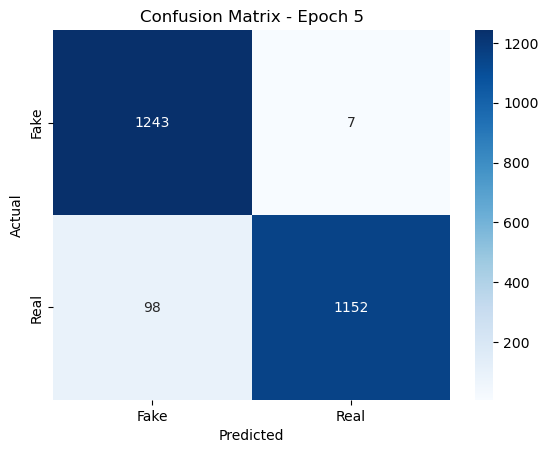

📊 Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.99      0.96      1250
        Real       0.99      0.92      0.96      1250

    accuracy                           0.96      2500
   macro avg       0.96      0.96      0.96      2500
weighted avg       0.96      0.96      0.96      2500



In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = 0.0

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}"), start=0):
        # Skip already-trained steps (if resuming)
        if epoch == start_epoch and step < start_step:
            continue

        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs["loss"]

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        global_step += 1

        # 💾 Save checkpoint every N steps
        if global_step % CHECKPOINT_INTERVAL == 0:
            torch.save({
                "epoch": epoch,
                "step": step + 1,  # resume from next step
                "global_step": global_step,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_acc": best_val_acc
            }, CHECKPOINT_PATH)
            print(f"💾 Checkpoint saved at step {global_step}")

    # 🔍 Evaluate at the end of each epoch
    val_acc, val_f1, trues, preds = evaluate(model, val_loader)
    avg_loss = total_loss / (len(train_loader) - start_step if epoch == start_epoch else len(train_loader))
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    
# Show confusion matrix
    cm = confusion_matrix(trues, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - Epoch {epoch+1}")
    plt.show()

# Print full classification report
    print("📊 Classification Report:")
    print(classification_report(trues, preds, target_names=["Fake", "Real"]))


    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_model.pth"))
        print("✅ Best model updated")
    
    # Reset step if epoch changes
    start_step = 0


## 6. Inference on the unlabeled test set

In [25]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import io
import pandas as pd
import torch

# --- Custom collate function to handle PIL images ---
def custom_collate_fn(batch):
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]
    return {"image": images, "text": texts}

# --- Define test dataset ---
class NewsTestDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(io.BytesIO(row['image']['bytes'])).convert("RGB")
        text = row['text']
        return {
            "image": image,
            "text": text
        }

# --- Create DataLoader ---
test_dataset = NewsTestDataset(test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate_fn)

# --- Inference ---
model.eval()
test_preds = []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"]
        texts = batch["text"]

        processed = processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        )
        processed = {k: v.to(DEVICE) for k, v in processed.items()}

        outputs = model(**processed)
        logits = outputs["logits"]
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)

# --- Save predictions to CSV ---
submission = pd.DataFrame({
    "id": test.index,   # use the index instead
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("✅ Submission file saved as submission.csv")


✅ Submission file saved as submission.csv


## 7. Predicting a single example and a Gradio demo

In [27]:
from PIL import Image
import torch

def predict_fake_real(image_path, caption, model, processor):
    """
    Given a new image and a text caption, predict whether the news is real or fake.
    """
    # Load and preprocess
    image = Image.open(image_path).convert("RGB")
    inputs = processor(text=caption, images=image, return_tensors="pt", padding=True, truncation=True, max_length=77)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    
    # Prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs["logits"]
        pred = torch.argmax(logits, dim=1).item()
    
    # Map to label
    label = "REAL" if pred == 1 else "FAKE"
    print(f"🖼️ Caption: {caption}")
    print(f"📢 Prediction: {label}")
    return label


In [29]:
predict_fake_real("test.jpg", "A massive storm has made landfall. Coastal cities are on high alert. Stay tuned for updates.", model, processor)


🖼️ Caption: A massive storm has made landfall. Coastal cities are on high alert. Stay tuned for updates.
📢 Prediction: FAKE


'FAKE'

In [31]:
import gradio as gr
from PIL import Image
import torch

def predict_fn(image, caption):
    # Preprocess input
    inputs = processor(text=caption, images=image, return_tensors="pt", padding=True, truncation=True, max_length=77)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs["logits"]
        pred = torch.argmax(logits, dim=1).item()
    
    return "✅ REAL" if pred == 1 else "❌ FAKE"

# Create Gradio interface
demo = gr.Interface(
    fn=predict_fn,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Textbox(lines=2, placeholder="Enter caption here", label="Caption")
    ],
    outputs="text",
    title="Fake News Detector",
    description="Upload an image and write a caption to check if it's fake or real news."
)

# Launch the app
demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
